<div class="alert alert-block alert-warning">
<span style="color: rgb(0,53,91);">
<center><img src="./Imagenes/ITESO_Logo.png" style="width:500px;height:142px;" title="Logo ITESO"></center>
<font face = "Times New Roman" size = "6"><b><center>Ingenierías ITESO</center></b></font>
<font face = "Times New Roman" size = "5"><b><center>Programación para Análisis de Datos</center></b></font>
<font face = "Times New Roman" size = "5"><center>Ejercicio 3: Ruido en Imágenes</center></font></b>
<div align="right"><font face = "Times New Roman" size = "2">Dr. Iván Esteban Villalón Turrubiates (villalon@iteso.mx)</font></div>
</span></div>

#### Nombre del Alumno: Santiago Nuñez Perez
#### Matrícula: 761552

#### Instrucciones:
Por favor, revisa cuidadosamente las siguientes instrucciones:

* Realiza este ejercicio de manera individual.
* Escribe tu nombre completo y matrícula en la celda correspondiente.
* Lee cuidadosamente cada uno de los ejercicios y realiza las acciones solicitadas.
* Coloca tu código ejecutable en las celdas debajo de la explicación de cada reactivo.
* Una vez terminado, sube en CANVAS sólamente el archivo `.ipynb` en la liga correspondiente.

#### Explicación:
Se realizará la agregación de **Ruido Blanco Gaussiano** a una imagen **RGB**.

<center><img src="./Imagenes/ConvRuido.png" style="width:730px;height:148px;" class="center"></center>

Para ello, se debe realizar el proceso de análisis por medio de los reactivos descritos a continuación, donde cada uno tiene un valor de **5 CRÉDITOS**, los cuales se agregarán al total acumulado de cada uno de los alumnos del curso.

**1.** Cargar las librerías **Scikit-Image**, **NumPy** y **Matplotlib** que serán empleadas. Posteriormente, cargar una imagen desde un archivo y mostrarla, la cual puede tener dimensiones distintas a *512x512* pixeles:

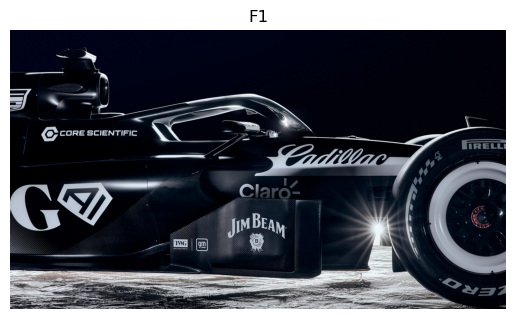

In [28]:
# Código del Reactivo 1
#Importación de Librerías
from skimage import io 
import numpy as np  
import matplotlib.pyplot as plt                                                 

#Lectura de la Imagen desde un archivo JPG
F1 = plt.imread("./Imagenes/CadillacF1.jpg")

#Asignación de los valores del número de renglones, columnas y bandas en la imagen
R = F1.shape[0]                        
C = F1.shape[1]                        
B = F1.shape[2]  

#Impresión de la Imagen
plt.imshow(F1)
plt.axis('off')
plt.title("F1")
plt.show()

**2.** Definir la **Función para Agregación de Ruido** que será empleada:

In [29]:
# Código del Reactivo 2
#Función para Agregación de Ruido
def imagenRuido(Imagen,med,des):

    #Inicialización de la imagen con ruido
    Ruido = np.zeros((R,C,B))               

    #Formación de la imagen con ruido
    for i in range(0,R):                     
        for j in range(0,C):
            for k in range(0,B):
                Ruido[i,j,k] = Imagen[i,j,k] + np.random.normal(med,des)
    return Ruido

**3.** Definir la función de **Normalización** que será empleada, considerando que se deben realizar las operaciones de normalización, escalamiento a 256 valores, y conversión a valores enteros:

In [30]:
# Código del Reactivo 3
def normalizacion(Imagen):
    #Inicializacion de la matriz normalizada
    ImaNormal=np.zeros((R,C,B))

    #Valores maximo y minimo para la banda R
    max_r=np.max(Imagen[:,:,0])
    min_r=np.min(Imagen[:,:,0])

    #Valores maximo y minimo para la banda G
    max_g=np.max(Imagen[:,:,1])
    min_g=np.min(Imagen[:,:,1])

    #Valores maximo y minimo para la banda B
    max_b=np.max(Imagen[:,:,2])
    min_b=np.min(Imagen[:,:,2])

    #Normalización de la imagen con ruido
    for i in range(0,R):                     
        for j in range(0,C):
            ImaNormal[i,j,0] = (Imagen[i,j,0] - min_r) / (max_r - min_r)
            ImaNormal[i,j,1] = (Imagen[i,j,1] - min_g) / (max_g - min_g)
            ImaNormal[i,j,2] = (Imagen[i,j,2] - min_b) / (max_b - min_b)

    #Escalamiento a escala de 0 a 255 (8 bits)
    ImaNormal8 = ImaNormal[:,:,:] * 255      

    #Imagen final con valores enteros
    ImaFinal = np.uint8(ImaNormal8)   

    return ImaFinal

**4.** Definir el valor de media y desviación estándar del **Ruido Blanco Gaussiano** que se va a agregar a la imagen, y posteriormente aplicar la **Función para Agregación de Ruido** así como la función de **Normalización** a la imagen del *reactivo 1*, mostrando el resultado y guardando una copia en formato ***JPG***:

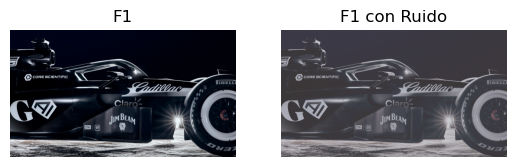

In [31]:
# Código del Reactivo 4
#Media y Desviación Estándar del Ruido
media = 80 
deest = 20

#Agregación de Ruido a la Imagen
AgregaRuido = imagenRuido(F1, media, deest) 

#Determinación de la Normalización
ImaRuido = normalizacion(AgregaRuido) 

#Impresión de la Imagen con Ruido
plt.subplot(1,2,1), plt.imshow(F1), plt.axis('off'), plt.title("F1")
plt.subplot(1,2,2), plt.imshow(ImaRuido), plt.axis('off'), plt.title("F1 con Ruido")
#plt.imsave('./Guardados/F1_Ruido.jpg', ImaRuido)
plt.show()

**5.** El ***Filtro Sharpen*** está definido por la siguiente matriz de 3x3:

\begin{Bmatrix}
0 & -3 & 0\\
-3 & 21 & -3\\
0 & -3 & 0
\end{Bmatrix}

Este filtro suele ser utilizado como un reductor de ruido en imágenes. Se aplicará este filtro a la imagen con **Ruido Blanco Gaussiano**, para ello se debe definir la **Función para la Convolución** así como la **Matriz de Convolución** que se aplicará como filtro. A partir de ello se puede aplicar la operación de **Convolución** con el ***Filtro Sharpen*** así como su **Normalización**, mostrando los resultados por medio de la imagen con **Ruido Blanco Gaussiano** junto a la imagen filtrada:

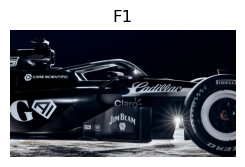

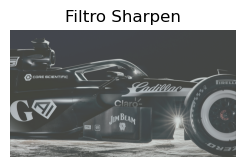

In [39]:
# Código del Reactivo 5
def convolucion(Imagen, Filtro):
    Conv = np.zeros((R, C, B))
    for b in range(0, B):
        # Para un filtro 3x3, empezamos en 1 y terminamos en R-1 y C-1
        for r in range(1, R-1):
            for c in range(1, C-1):
                Ventana = np.array(Imagen[r-1:r+2, c-1:c+2, b])  # Ventana 3x3
                Multiplica = Ventana * Filtro                    # ¡Multiplicación correcta!
                Suma = np.sum(Multiplica)
                Conv[r, c, b] = Suma
    return Conv

    
Filtro = np.array([[0, -3, 0],[-3, 21, -3],[0, -3, 0]]) 

#Determinación de la Convolución
Conv = convolucion(F1, Filtro)

#Determinación de la Normalización
ImaConv = normalizacion(Conv)

#Media y Desviación Estándar del Ruido
media = 80 
deest = 20

#Agregación de Ruido a la Imagen
AgregaRuido = imagenRuido(F1, media, deest) 

#Determinación de la Normalización
ImaRuido = normalizacion(AgregaRuido) 

#Impresión de la Imagen con Ruido
plt.subplot(1,2,1), plt.imshow(F1), plt.axis('off'), plt.title("F1")
plt.subplot(1,2,2), plt.imshow(ImaRuido), plt.axis('off'), plt.title("F1 con Ruido")
#plt.imsave('./Guardados/F1_Ruido.jpg', ImaRuido)
plt.show()

#Impresión del Resultado
plt.subplot(1,2,2), plt.imshow(ImaRuido), plt.axis('off'), plt.title("F1 con Ruido")
plt.subplot(1,2,2), plt.imshow(ImaConv), plt.axis('off'), plt.title("Filtro Sharpen")
#plt.imsave('./Guardados/ImaConv_Sha.jpg', ImaConv)
plt.show()

<div class="alert alert-block alert-danger">
<b>.: Fin del Ejercicio 2 :.</b>
</div>